In [307]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score


In [308]:
df = pd.read_csv('data.csv')

In [309]:
df.head()

,name,age,weight,height,DOB
0,John Doe,34.0,78.5,175.2,1990-03-12
1,Jane Smith,NaN,NaN,168.5,1985-07-21
2,Bob Johnson,45.0,95.2,180.0,1979-11-02
3,Alice Brown,23.0,55.3,162.3,2001-05-14
4,Charlie Wilson,67.0,82.1,NaN,1957-08-30


In [310]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    143 non-null    str    
 1   age     142 non-null    float64
 2   weight  148 non-null    float64
 3   height  148 non-null    float64
 4   DOB     150 non-null    str    
dtypes: float64(3), str(2)
memory usage: 10.8 KB


In [311]:
# count null values
df.isnull().sum()

name      49
age       50
weight    44
height    44
DOB       42
dtype: int64

In [312]:
# simple imputer 
from sklearn.impute import SimpleImputer
name_imputer = SimpleImputer(strategy='most_frequent')
df['name'] = name_imputer.fit_transform(df[['name']]).ravel()

age_imputer = SimpleImputer(strategy='mean')
df['age'] = age_imputer.fit_transform(df[['age']]).ravel()

weight_imputer = SimpleImputer(strategy='mean')
df['weight'] = weight_imputer.fit_transform(df[['weight']]).ravel()

height_imputer = SimpleImputer(strategy='mean')
df['height'] = height_imputer.fit_transform(df[['height']]).ravel()

DOB_imputer = SimpleImputer(strategy='most_frequent')
df['DOB'] = DOB_imputer.fit_transform(df[['DOB']]).ravel()

In [313]:
df.isnull().sum()

name      0
age       0
weight    0
height    0
DOB       0
dtype: int64

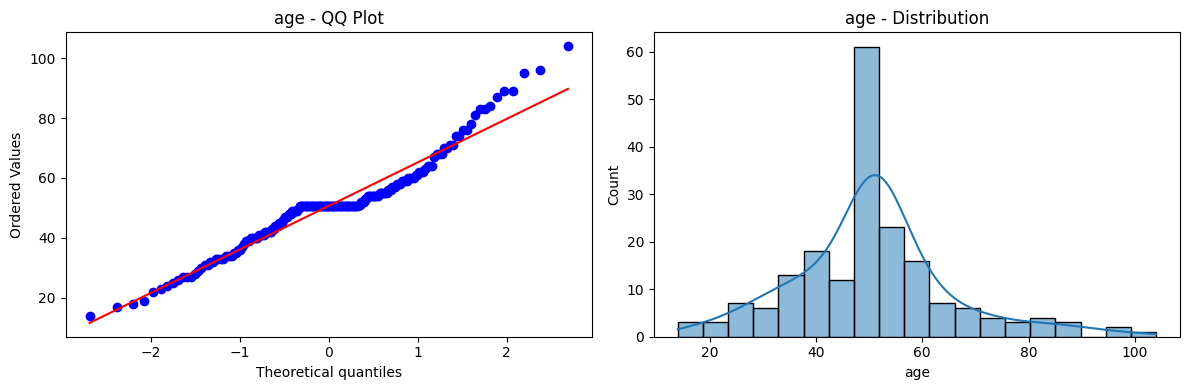

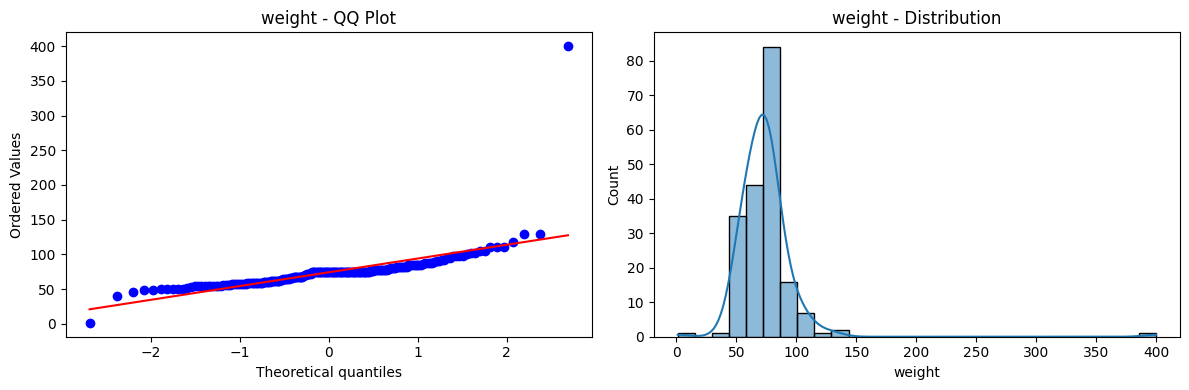

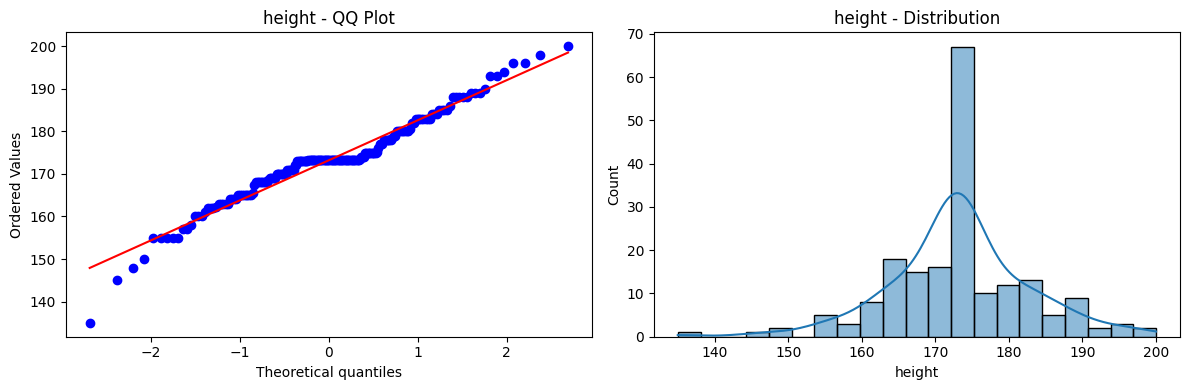

In [314]:
# qq plot and distribution side by side
from scipy import stats

columnsName = ['age', 'weight', 'height']
for column in columnsName:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # QQ plot on left
    stats.probplot(df[column], dist="norm", plot=ax1)
    ax1.set_title(f'{column} - QQ Plot')
    
    # Distribution plot on right
    sns.histplot(df[column], kde=True, ax=ax2)
    ax2.set_title(f'{column} - Distribution')
    
    plt.tight_layout()
    plt.show()

In [315]:
# checking in these columns [height, age, weight] have negative values or not

print("Negative values in 'height':", (df['height'] < 0).sum())
print("Negative values in 'age':", (df['age'] < 0).sum())
print("Negative values in 'weight':", (df['weight'] < 0).sum())

Negative values in 'height': 0
Negative values in 'age': 0
Negative values in 'weight': 0


In [316]:
# calling power transformer for age, weight and height
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()

age_power_transformed = pt.fit_transform(df[['age']])
weight_power_transformed = pt.fit_transform(df[['weight']])
height_power_transformed = pt.fit_transform(df[['height']])

# converting to dataframe
age_power_transformed_df = pd.DataFrame(age_power_transformed, columns=['age_power_transformed'])
weight_power_transformed_df = pd.DataFrame(weight_power_transformed, columns=['weight_power_transformed'])
height_power_transformed_df = pd.DataFrame(height_power_transformed, columns=['height_power_transformed'])  
# concatenating the new columns to the original dataframe
df = pd.concat([df, age_power_transformed_df, weight_power_transformed_df, height_power_transformed_df], axis=1)    
df.drop(['age', 'weight', 'height'], axis=1, inplace=True)


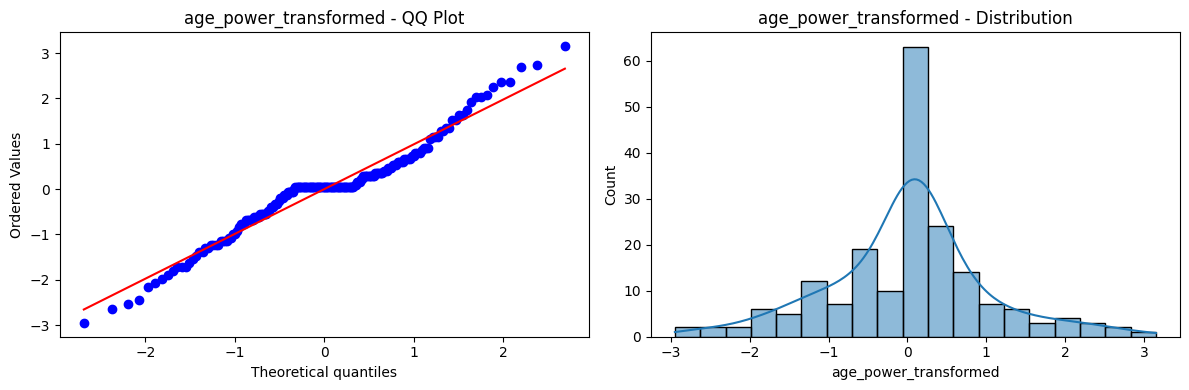

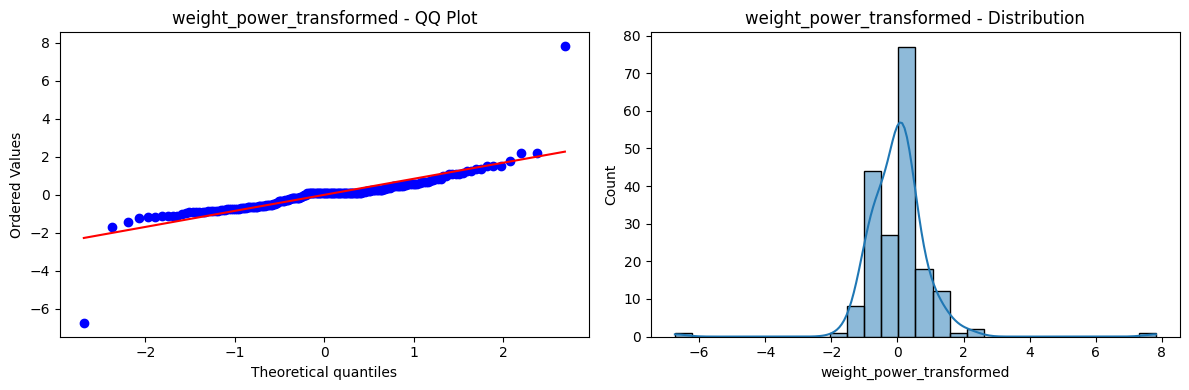

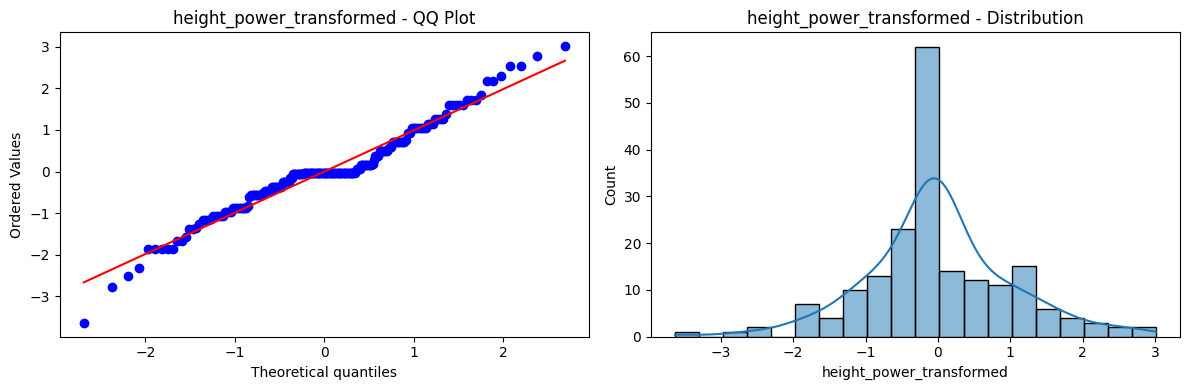

In [317]:
anotherColumnsName = ['age_power_transformed', 'weight_power_transformed', 'height_power_transformed']
for column in anotherColumnsName:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # QQ plot on left
    stats.probplot(df[column], dist="norm", plot=ax1)
    ax1.set_title(f'{column} - QQ Plot')
    
    # Distribution plot on right
    sns.histplot(df[column], kde=True, ax=ax2)
    ax2.set_title(f'{column} - Distribution')
    
    plt.tight_layout()
    plt.show()

Feature Construction

In [318]:
# feature construction
bmi_array = df['weight_power_transformed'] / (df['height_power_transformed'] ** 2)
bmi_array
bmi_df = pd.DataFrame(bmi_array, columns=['BMI'])
bmi_df.head()
df = pd.concat([df, bmi_df], axis=1)
df.head()

,name,DOB,age_power_transformed,weight_power_transformed,height_power_transformed,BMI
0,John Doe,1990-03-12,-1.146375,0.291482,0.185898,8.434545
1,Jane Smith,1985-07-21,0.055490,0.098223,-0.516328,0.368436
2,Bob Johnson,1979-11-02,-0.332594,0.972263,0.705067,1.955796
3,Alice Brown,2001-05-14,-2.066065,-0.829946,-1.142817,-0.635472
4,Charlie Wilson,1957-08-30,1.098460,0.445551,-0.026390,639.765625


Feature Spiliting

In [319]:
# You created 'first' and 'last' Series
first = df['name'].apply(lambda x: x.split()[0] if pd.notna(x) and len(x.split()) > 0 else None)
last = df['name'].apply(lambda x: x.split()[1] if pd.notna(x) and len(x.split()) > 1 else None)

df['firstName'] = first
df['lastName'] = last


df.drop(['name'], axis=1, inplace=True)
df.head()


,DOB,age_power_transformed,weight_power_transformed,height_power_transformed,BMI,firstName,lastName
0,1990-03-12,-1.146375,0.291482,0.185898,8.434545,John,Doe
1,1985-07-21,0.055490,0.098223,-0.516328,0.368436,Jane,Smith
2,1979-11-02,-0.332594,0.972263,0.705067,1.955796,Bob,Johnson
3,2001-05-14,-2.066065,-0.829946,-1.142817,-0.635472,Alice,Brown
4,1957-08-30,1.098460,0.445551,-0.026390,639.765625,Charlie,Wilson


Feature Spiliting

In [320]:
# Your current code works but has a small logic issue
# "if dob_split.shape[1] > 0" will ALWAYS be True because split always gives at least 1 column

# Better way:
dob_split = df['DOB'].str.split('-', expand=True)

df['DOB_year'] = dob_split[0]  # Always exists
df['DOB_month'] = dob_split[1] 
df['DOB_day'] = dob_split[2] 

# Or simply (since all your dates have 3 parts):
df['DOB_year'] = dob_split[0]
df['DOB_month'] = dob_split[1]
df['DOB_day'] = dob_split[2]

In [321]:
df.head()

,DOB,age_power_transformed,weight_power_transformed,height_power_transformed,BMI,firstName,lastName,DOB_year,DOB_month,DOB_day
0,1990-03-12,-1.146375,0.291482,0.185898,8.434545,John,Doe,1990,03,12
1,1985-07-21,0.055490,0.098223,-0.516328,0.368436,Jane,Smith,1985,07,21
2,1979-11-02,-0.332594,0.972263,0.705067,1.955796,Bob,Johnson,1979,11,02
3,2001-05-14,-2.066065,-0.829946,-1.142817,-0.635472,Alice,Brown,2001,05,14
4,1957-08-30,1.098460,0.445551,-0.026390,639.765625,Charlie,Wilson,1957,08,30


In [322]:
df.drop(['DOB'], axis=1, inplace=True)

In [323]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age_power_transformed     192 non-null    float64
 1   weight_power_transformed  192 non-null    float64
 2   height_power_transformed  192 non-null    float64
 3   BMI                       192 non-null    float64
 4   firstName                 192 non-null    str    
 5   lastName                  189 non-null    str    
 6   DOB_year                  192 non-null    str    
 7   DOB_month                 192 non-null    str    
 8   DOB_day                   192 non-null    str    
dtypes: float64(4), str(5)
memory usage: 17.1 KB


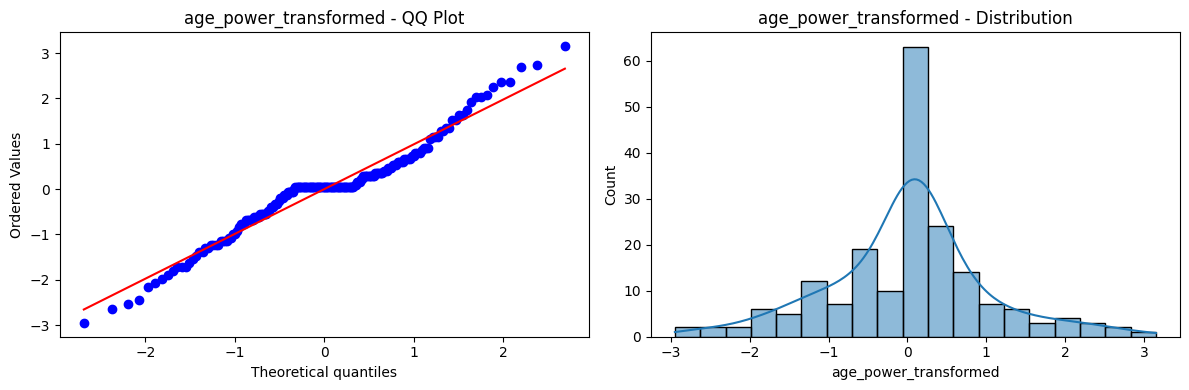

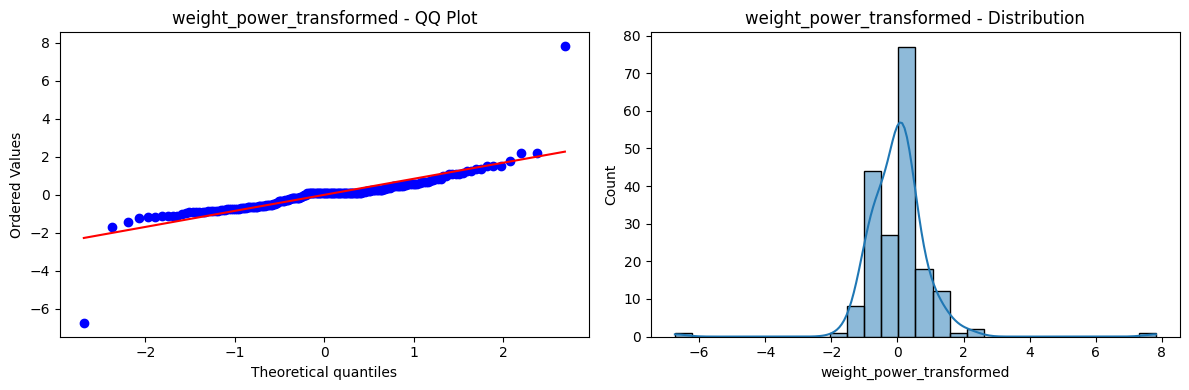

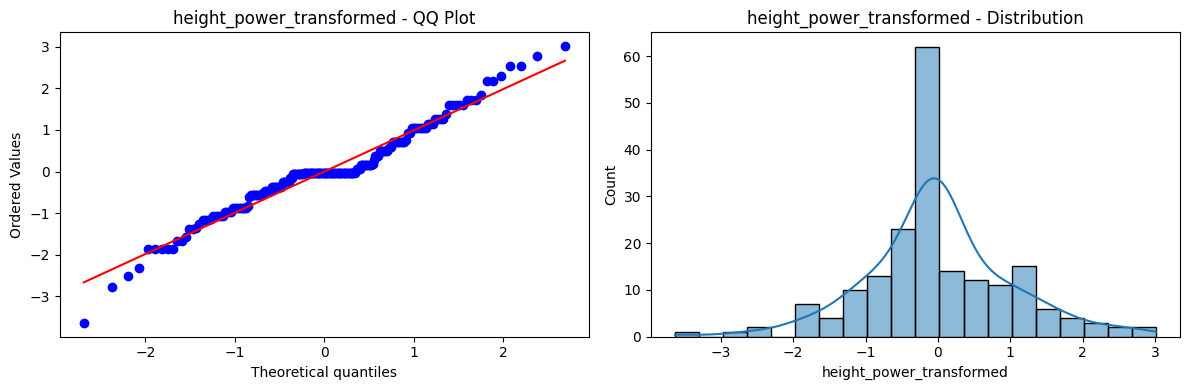

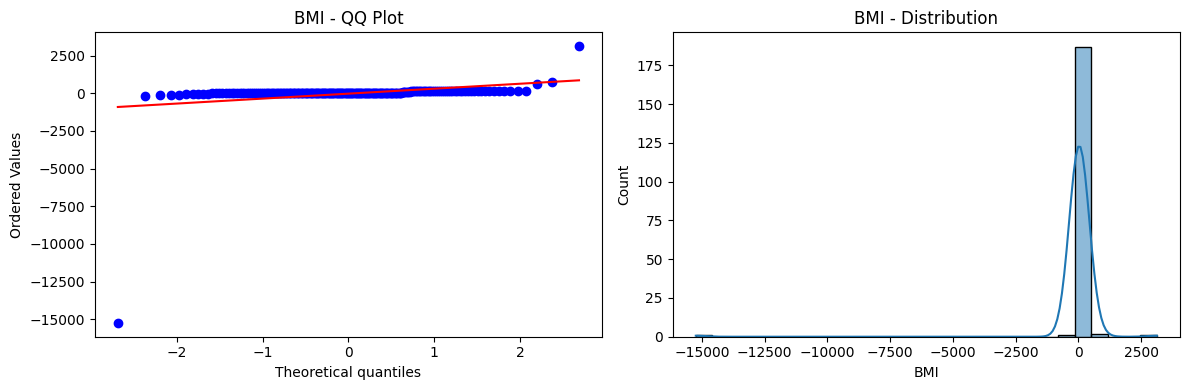

In [325]:
new_cols = ['age_power_transformed', 'weight_power_transformed', 'height_power_transformed', 'BMI']

for column in new_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # QQ plot on left
    stats.probplot(df[column], dist="norm", plot=ax1)
    ax1.set_title(f'{column} - QQ Plot')
    
    # Distribution plot on right
    sns.histplot(df[column], kde=True, ax=ax2)
    ax2.set_title(f'{column} - Distribution')
    
    plt.tight_layout()
    plt.show()
    

In [326]:
# standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[new_cols] = scaler.fit_transform(df[new_cols])


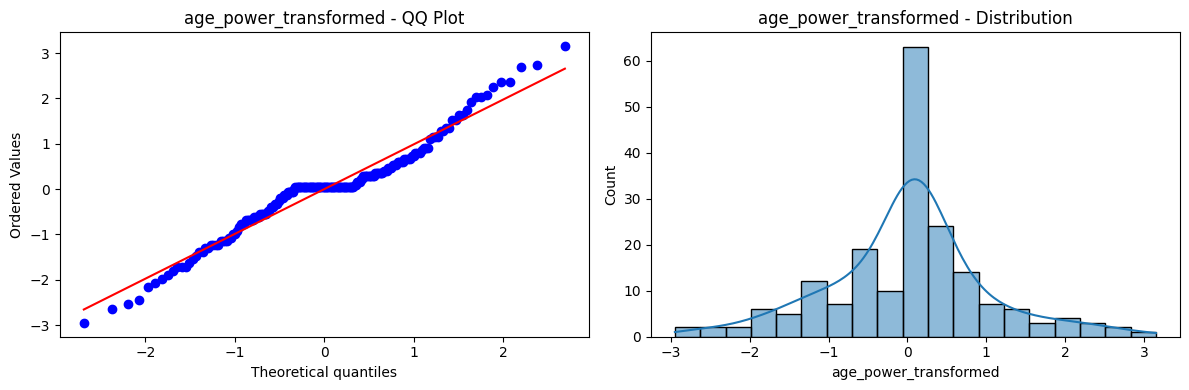

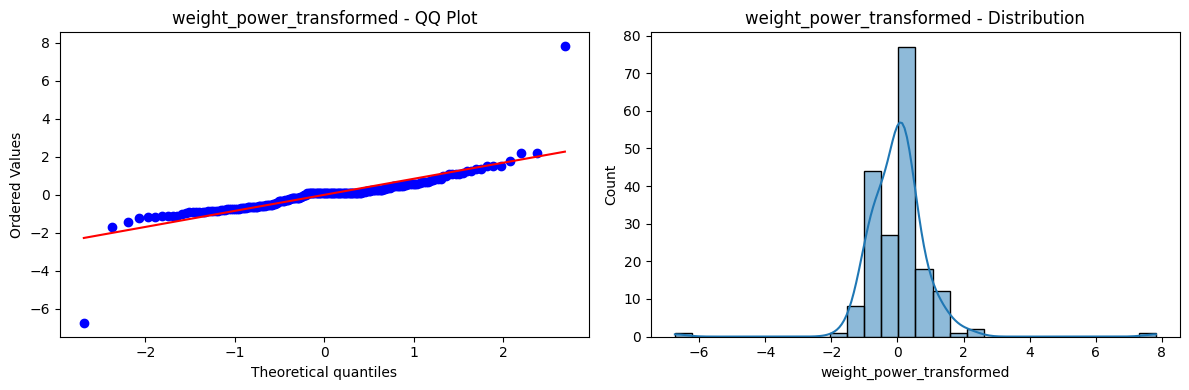

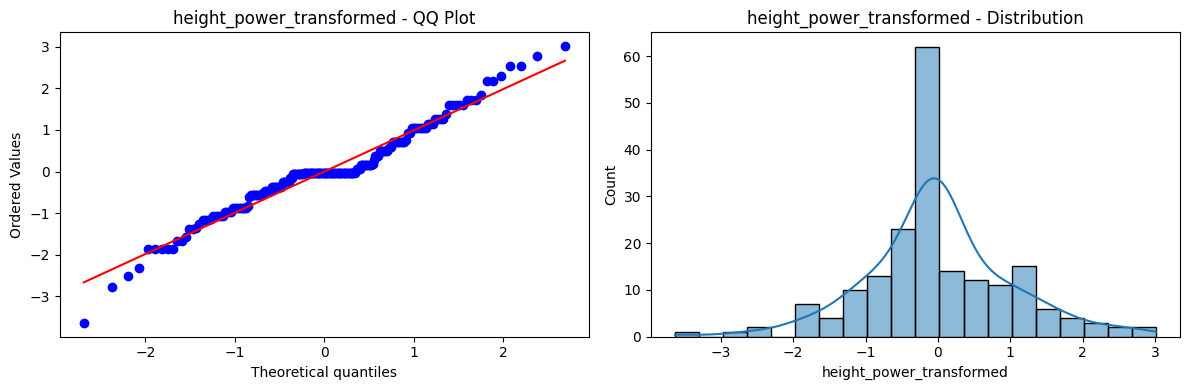

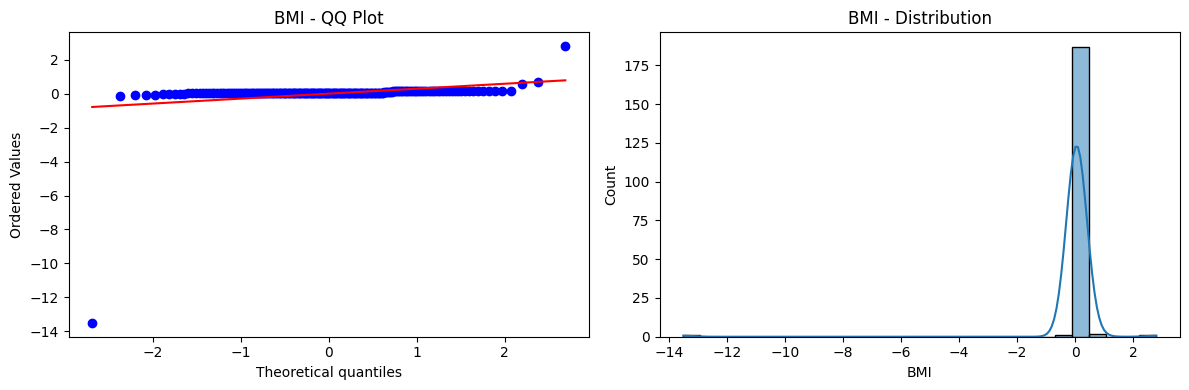

In [327]:
for column in new_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # QQ plot on left
    stats.probplot(df[column], dist="norm", plot=ax1)
    ax1.set_title(f'{column} - QQ Plot')
    
    # Distribution plot on right
    sns.histplot(df[column], kde=True, ax=ax2)
    ax2.set_title(f'{column} - Distribution')
    
    plt.tight_layout()
    plt.show()

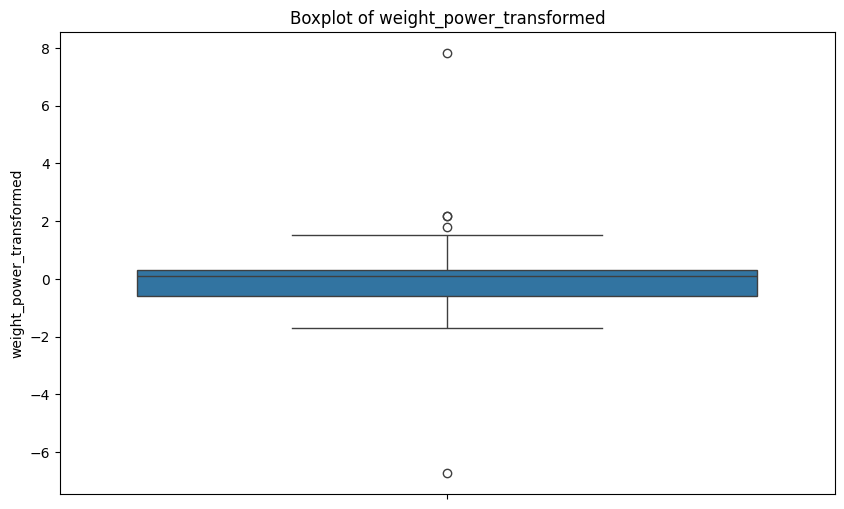

In [328]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['weight_power_transformed'])
plt.title('Boxplot of weight_power_transformed')
plt.show()
